MODEL Z PCA 
CV scores: [0.93333333 0.86666667 0.92200557 0.9275766  0.88300836]
Mean accuracy: 0.9065181058495823

 MODEL BEZ PCA 
CV scores: [0.91388889 0.88055556 0.94428969 0.9637883  0.89972145]
Mean accuracy: 0.9204487774682761


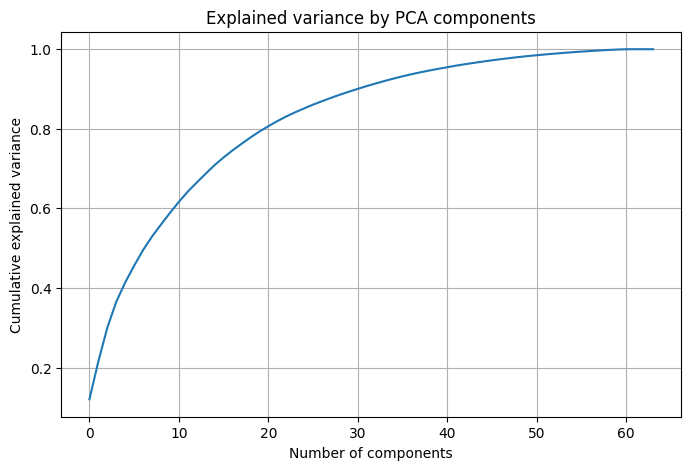

In [1]:
# Stwórz sklearn Pipeline z StandardScaler + PCA + LogisticRegression.
# Dataset: Digits
# Wymagania:
# Pipeline z 3 krokami
# Cross-validation na całym pipeline
# Porównaj z modelem bez PCA

import numpy as np
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Wczytanie datasetu

digits = load_digits()

X = digits.data # macierz cech
y = digits.target #etykieta klas


# Pipeline z PCA

pipeline_pca = Pipeline([
    ("scaler", StandardScaler()), #skalowanie wszystkich cech
    ("pca", PCA(n_components=30)),

    ("logreg", LogisticRegression(max_iter=5000))
])

#PCA będzie faworyzować duże wartości.
#Dlatego scaling prawie zawsze robi się przed PCA.

# Cross-validation -> dzieli dane na 5 części

scores_pca = cross_val_score(
    pipeline_pca,
    X,
    y,
    cv=5,
    scoring="accuracy"
)


# Pipeline bez PCA

pipeline_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

scores_no_pca = cross_val_score(
    pipeline_no_pca,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

# Wyniki

print("MODEL Z PCA ")
print("CV scores:", scores_pca)
print("Mean accuracy:", np.mean(scores_pca))

print()

print(" MODEL BEZ PCA ")
print("CV scores:", scores_no_pca)
print("Mean accuracy:", np.mean(scores_no_pca))

# Wizualizacja

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(8, 5))

plt.plot(
    np.cumsum(pca_full.explained_variance_ratio_)
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")

plt.title("Explained variance by PCA components")

plt.grid(True)

plt.show()

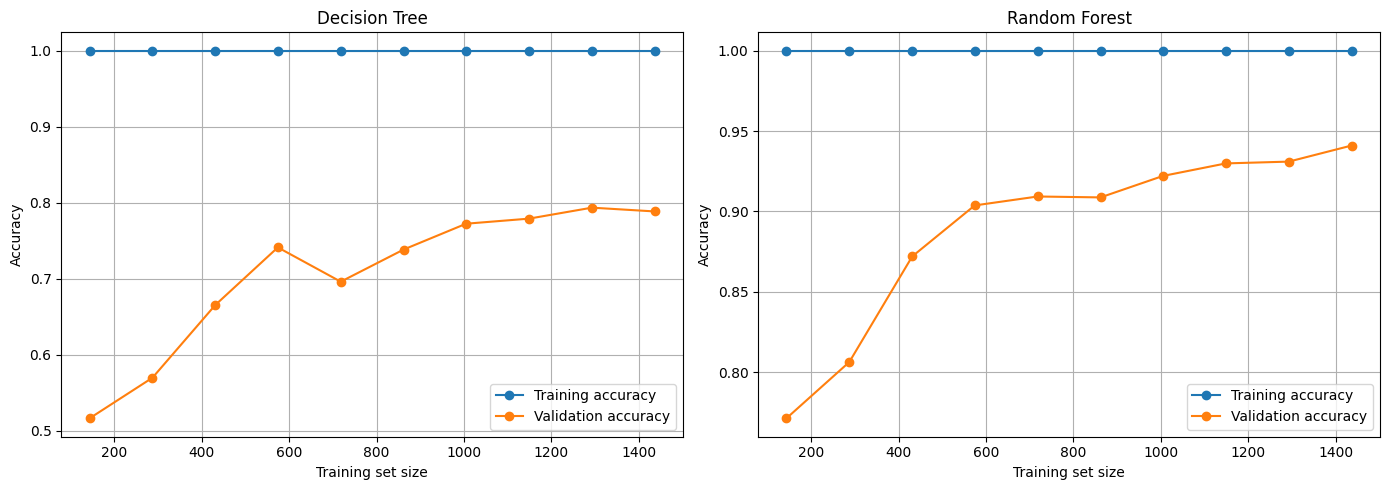

In [5]:
# Wygeneruj i zinterpretuj learning curves dla dwóch modeli.
# Dataset: Digits
# Wymagania:
# Decision Tree (max_depth=None) - potencjalny overfitting
# Random Forest (n_estimators=50, max_depth=5) - zbalansowany
# Wykresy obok siebie z interpretacją

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

digits = load_digits()
X, y = digits.data, digits.target

# model
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=None, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,
random_state=42)
}

# Wykres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, model) in zip(axes, models.items()):

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    # średnie accuracy
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)


    # Wykres
  
    ax.plot(
        train_sizes,
        train_mean,
        label="Training accuracy",
        marker="o"
    )

    ax.plot(
        train_sizes,
        val_mean,
        label="Validation accuracy",
        marker="o"
    )

    ax.set_title(title)

    ax.set_xlabel("Training set size")
    ax.set_ylabel("Accuracy")

    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()